# HW3: M5 Price Elasticity and Forecasting

Цель:

- выбрать несколько SKU с частыми продажами и как минимум 10 разными ценами;
- оценить ценовую эластичность каждого SKU и решить, подходит ли он для промо;
- сравнить 3 способа прогноза спроса на отложенном горизонте 28 дней.


## План анализа

1. Скачать и подготовить датасет M5.
2. Автоматически выбрать SKU с высокой частотой продаж и богатой ценовой историей.
3. Построить кривую эластичности по каждому SKU.
4. Сравнить три прогноза:
   - без знания будущей цены;
   - с будущей ценой как признаком модели;
   - базовая модель + кривая спроса от цены.


In [1]:
from pathlib import Path
import json

import pandas as pd
from IPython.display import Image, Markdown, display

from hw3.pipeline import default_config, run_pipeline

PROJECT_DIR = Path.cwd()
CONFIG = default_config(PROJECT_DIR)
TABLES_DIR = CONFIG.tables_dir
FIGURES_DIR = CONFIG.figures_dir


In [2]:
if not (TABLES_DIR / "analysis_summary.json").exists():
    run_pipeline(CONFIG)

with open(TABLES_DIR / "analysis_summary.json", "r", encoding="utf-8") as file:
    summary_payload = json.load(file)

selected_skus = pd.read_csv(TABLES_DIR / "selected_skus.csv")
elasticity_summary = pd.read_csv(TABLES_DIR / "elasticity_summary.csv")
metrics_by_sku = pd.read_csv(TABLES_DIR / "forecast_metrics_by_sku.csv")
method_summary = pd.read_csv(TABLES_DIR / "forecast_method_summary.csv")
final_recommendations = pd.read_csv(TABLES_DIR / "final_recommendations.csv")
predictions = pd.read_csv(TABLES_DIR / "holdout_predictions.csv", parse_dates=["date"])


## Выбранные SKU

In [3]:
selected_skus[
    [
        "sku_id",
        "dept_id",
        "cat_id",
        "positive_sales_ratio",
        "total_sales",
        "unique_prices",
        "min_price",
        "median_price",
        "max_price",
    ]
].round(3)


,sku_id,dept_id,cat_id,positive_sales_ratio,total_sales,unique_prices,min_price,median_price,max_price
0,TX_2|FOODS_1_012,FOODS_1,FOODS,0.916,15671,13,5.61,5.93,6.71
1,WI_1|FOODS_1_096,FOODS_1,FOODS,0.868,11060,17,7.02,7.89,9.00
2,TX_2|FOODS_1_170,FOODS_1,FOODS,0.876,6810,13,5.61,5.93,6.71
3,TX_3|FOODS_1_087,FOODS_1,FOODS,0.867,7014,13,5.61,5.93,6.71
4,TX_2|FOODS_1_129,FOODS_1,FOODS,0.742,6757,16,5.93,6.48,6.91


## Методика

- `Модель 1`: градиентный бустинг по лагам, календарю и SNAP, но без цены будущего периода.
- `Модель 2`: тот же тип модели, но с признаками текущей цены.
- `Модель 3`: прогноз `Модели 1`, скорректированный через отдельную монотонную кривую эластичности.

Кривая эластичности оценивается как связь между ценой и мультипликатором спроса относительно базового прогноза без цены.


## Итоги по эластичности

In [4]:
elasticity_summary.sort_values("local_elasticity")[[
    "sku_id",
    "unique_prices",
    "local_elasticity",
    "promo_lift",
    "recommendation",
]]


,sku_id,unique_prices,local_elasticity,promo_lift,recommendation
4,TX_2|FOODS_1_129,16,-3.598234,4.935556e-01,promo
1,WI_1|FOODS_1_096,17,-0.239787,5.256598e-02,regular
3,TX_3|FOODS_1_087,13,-0.220322,1.282653e-02,regular
0,TX_2|FOODS_1_012,13,-0.019848,0.000000e+00,regular
2,TX_2|FOODS_1_170,13,-0.000003,2.516404e-07,regular


## Качество прогноза

In [5]:
method_summary.assign(
    mae=lambda df: df["mae"].round(3),
    rmse=lambda df: df["rmse"].round(3),
    wape=lambda df: df["wape"].round(3),
    bias=lambda df: df["bias"].round(3),
)


,method,mae,rmse,wape,bias
0,pred_with_price,2.640,3.517,0.463,0.265
1,pred_no_price,2.707,3.595,0.479,0.385
2,pred_curve_adjusted,3.071,4.011,0.566,0.977


In [6]:
metrics_by_sku.assign(
    mae=lambda df: df["mae"].round(3),
    rmse=lambda df: df["rmse"].round(3),
    wape=lambda df: df["wape"].round(3),
    bias=lambda df: df["bias"].round(3),
).sort_values(["sku_id", "wape"])


,sku_id,method,mae,rmse,wape,bias
1,TX_2|FOODS_1_012,pred_with_price,2.492,3.191,0.271,1.004
2,TX_2|FOODS_1_012,pred_curve_adjusted,2.515,3.264,0.274,0.865
0,TX_2|FOODS_1_012,pred_no_price,2.522,3.268,0.275,0.881
13,TX_2|FOODS_1_129,pred_with_price,2.037,2.360,0.479,0.816
12,TX_2|FOODS_1_129,pred_no_price,2.274,2.740,0.535,1.650
14,TX_2|FOODS_1_129,pred_curve_adjusted,4.177,4.837,0.983,4.128
8,TX_2|FOODS_1_170,pred_curve_adjusted,2.234,3.437,0.574,-0.387
7,TX_2|FOODS_1_170,pred_with_price,2.253,3.373,0.579,-0.119
6,TX_2|FOODS_1_170,pred_no_price,2.279,3.427,0.585,-0.158
10,TX_3|FOODS_1_087,pred_with_price,2.529,3.338,0.723,0.134


## Выводы по SKU

In [7]:
for narrative in summary_payload["narratives"]:
    display(Markdown(f"- {narrative}"))


- TX_2|FOODS_1_012: лучшая WAPE у подхода 'с будущей ценой в модели' (0.271). Локальная эластичность -0.02, ожидаемый lift на промо 0.0%, рекомендация: regular.

- WI_1|FOODS_1_096: лучшая WAPE у подхода 'модель + кривая эластичности' (0.260). Локальная эластичность -0.24, ожидаемый lift на промо 5.3%, рекомендация: regular.

- TX_2|FOODS_1_170: лучшая WAPE у подхода 'модель + кривая эластичности' (0.574). Локальная эластичность -0.00, ожидаемый lift на промо 0.0%, рекомендация: regular.

- TX_3|FOODS_1_087: лучшая WAPE у подхода 'с будущей ценой в модели' (0.723). Локальная эластичность -0.22, ожидаемый lift на промо 1.3%, рекомендация: regular.

- TX_2|FOODS_1_129: лучшая WAPE у подхода 'с будущей ценой в модели' (0.479). Локальная эластичность -3.60, ожидаемый lift на промо 49.4%, рекомендация: promo.

## Визуализации

### TX_2|FOODS_1_012

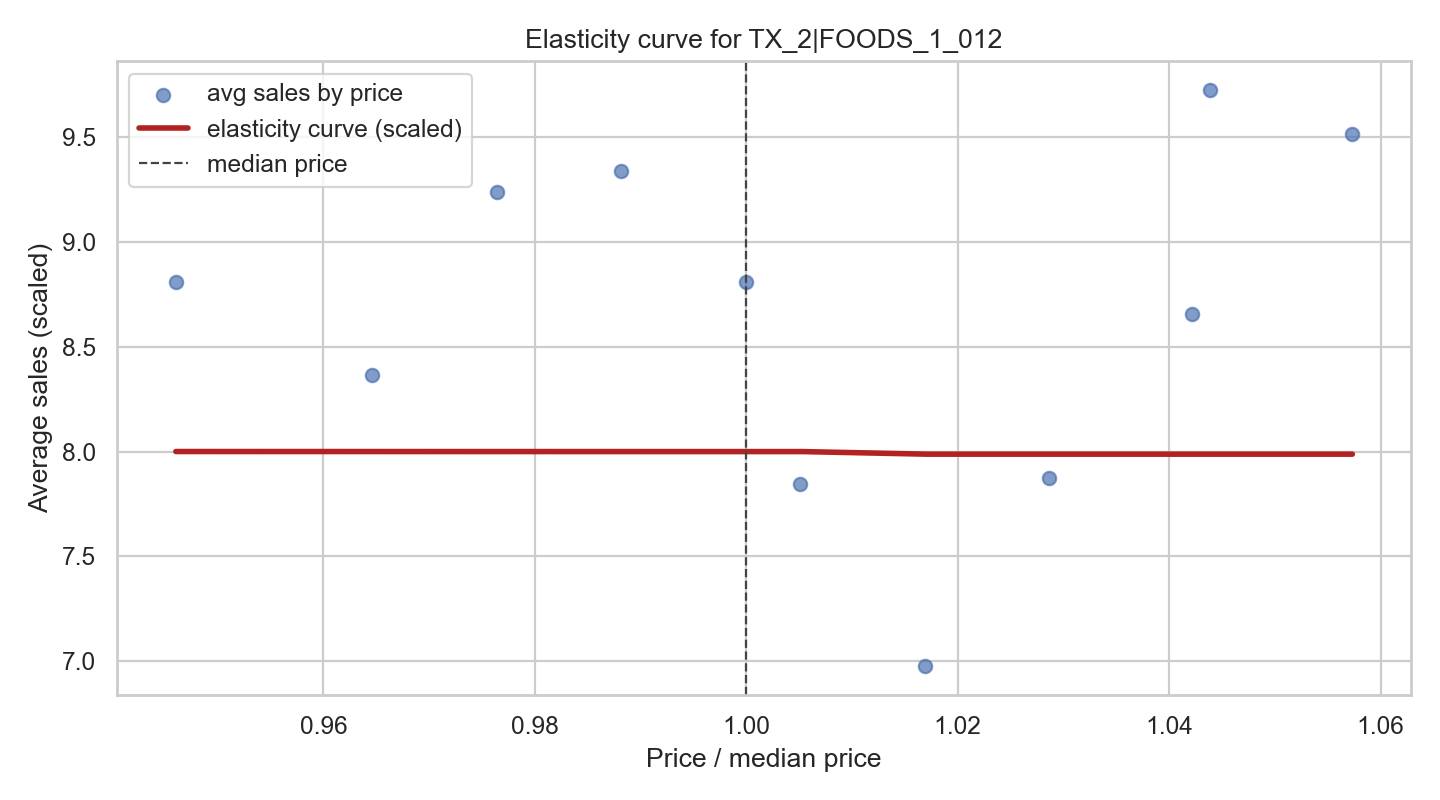

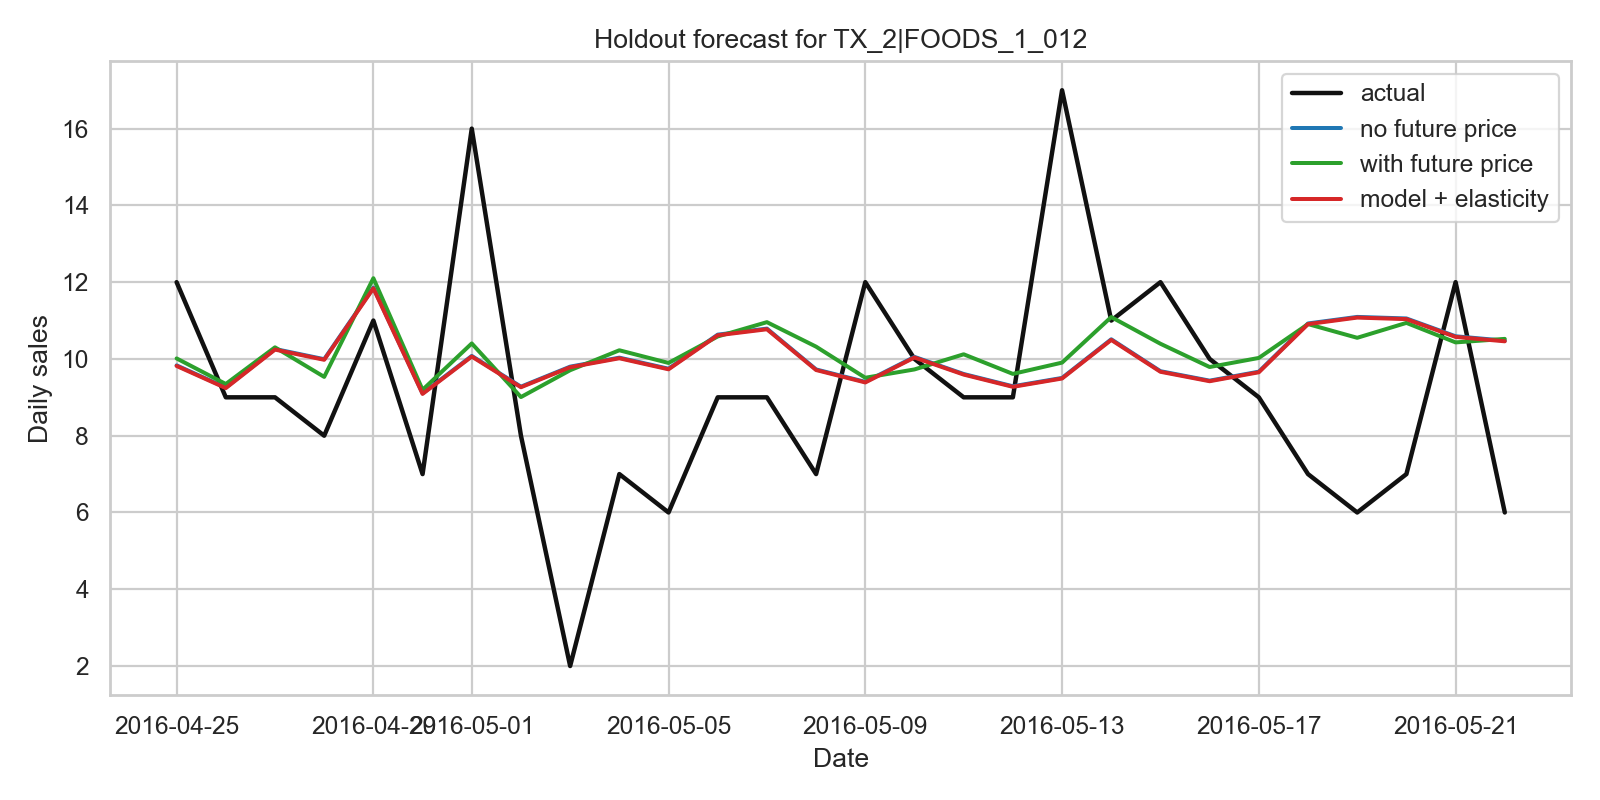

### WI_1|FOODS_1_096

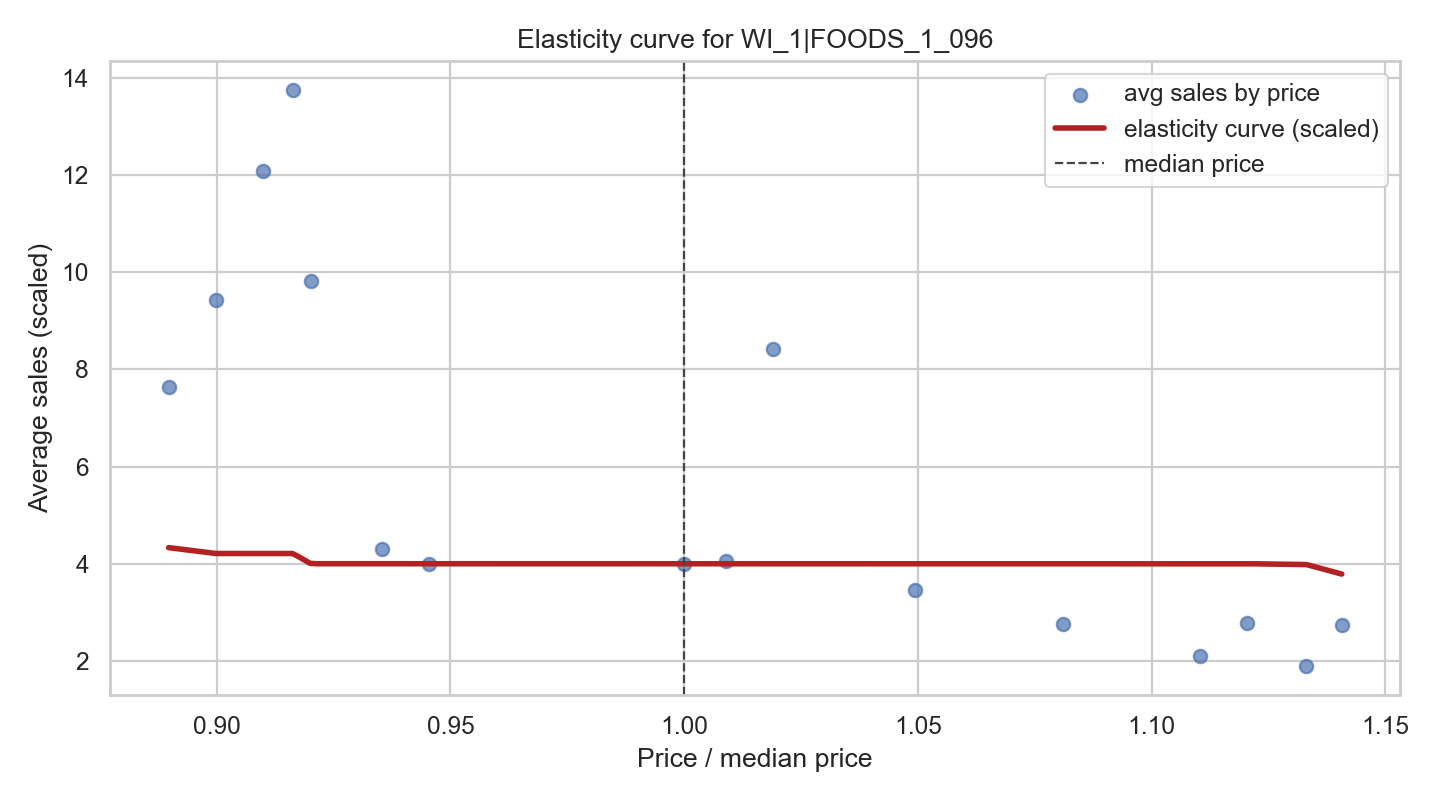

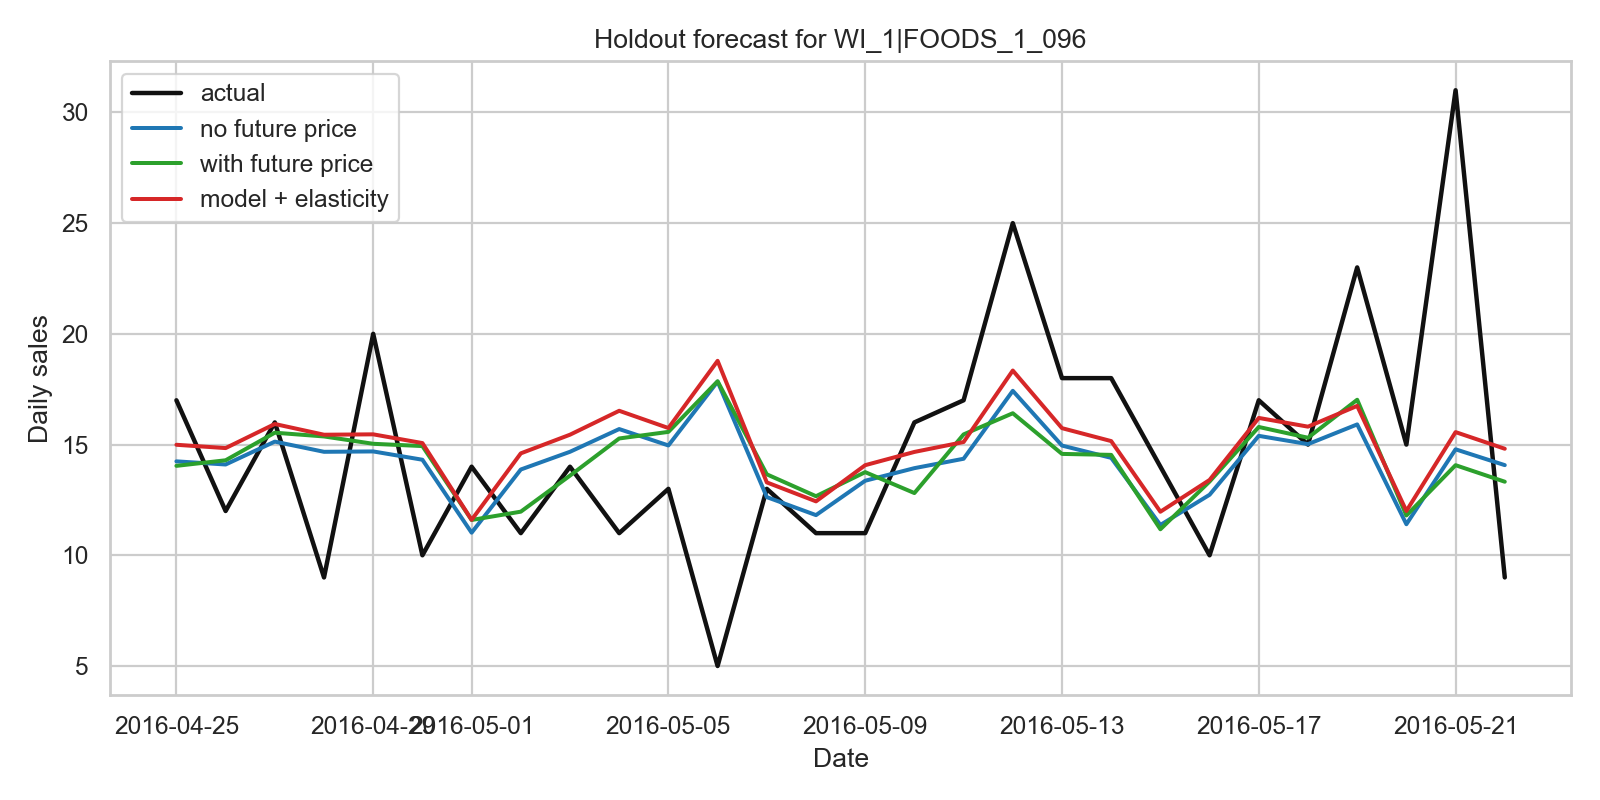

### TX_2|FOODS_1_170

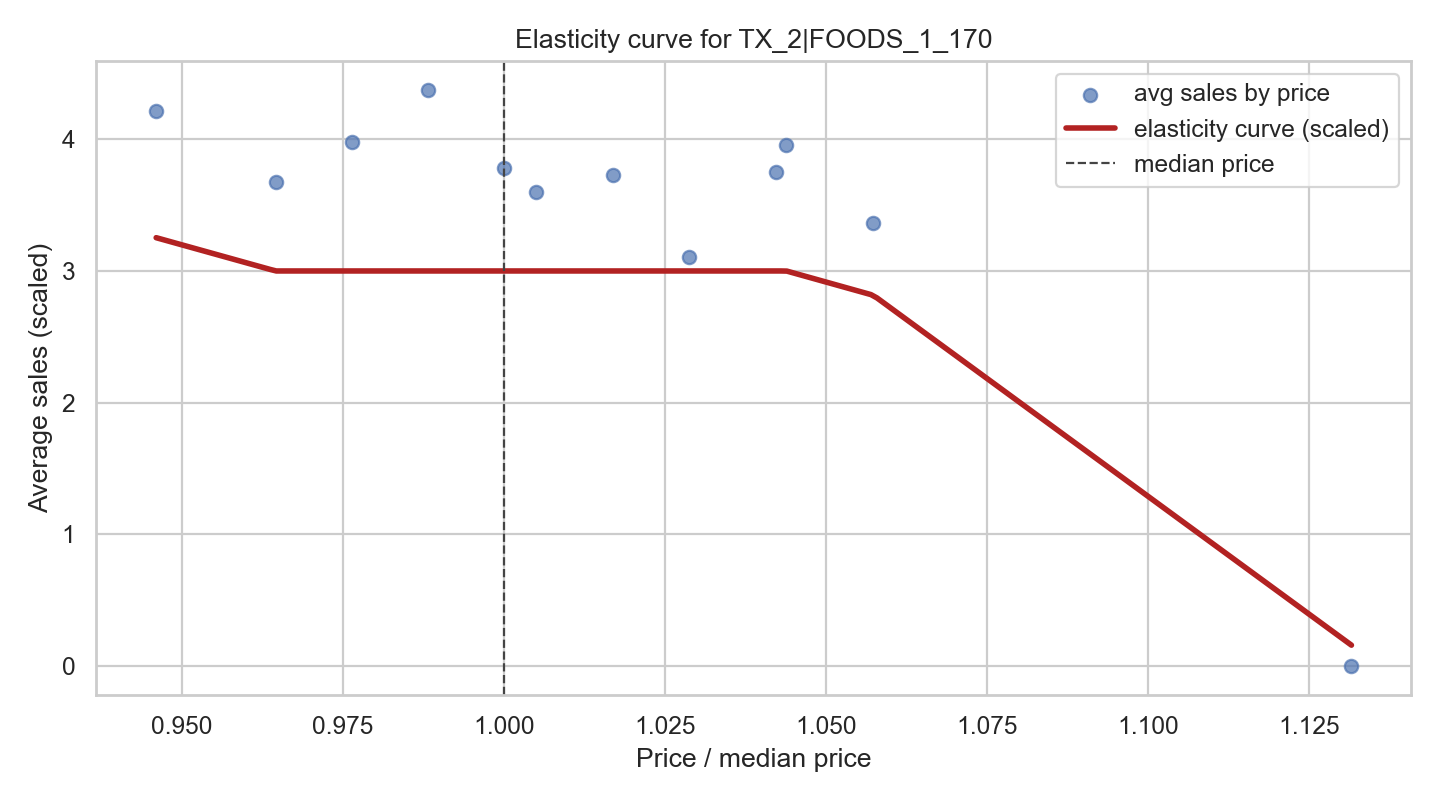

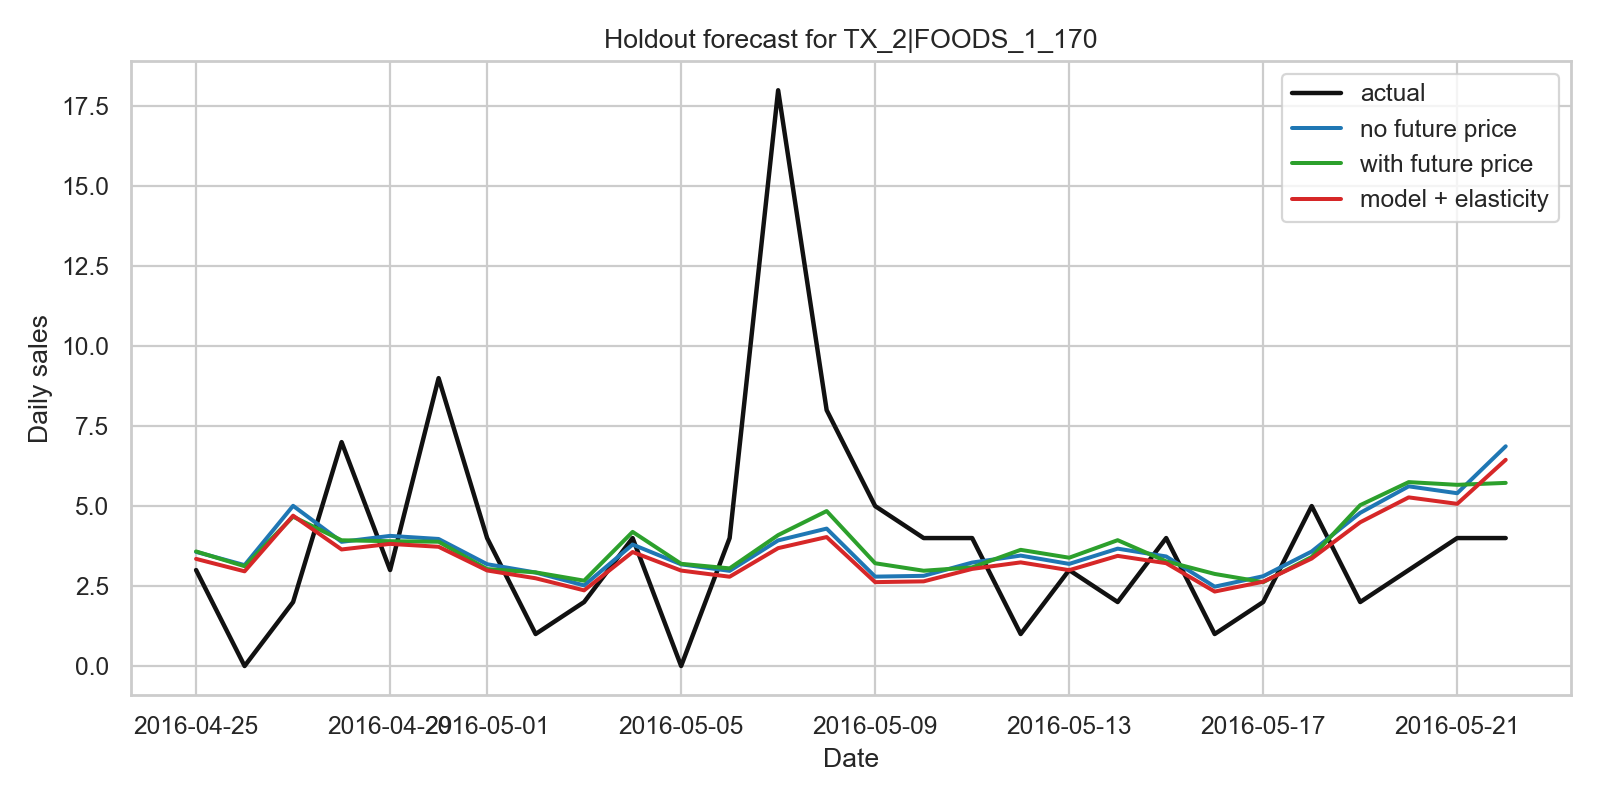

### TX_3|FOODS_1_087

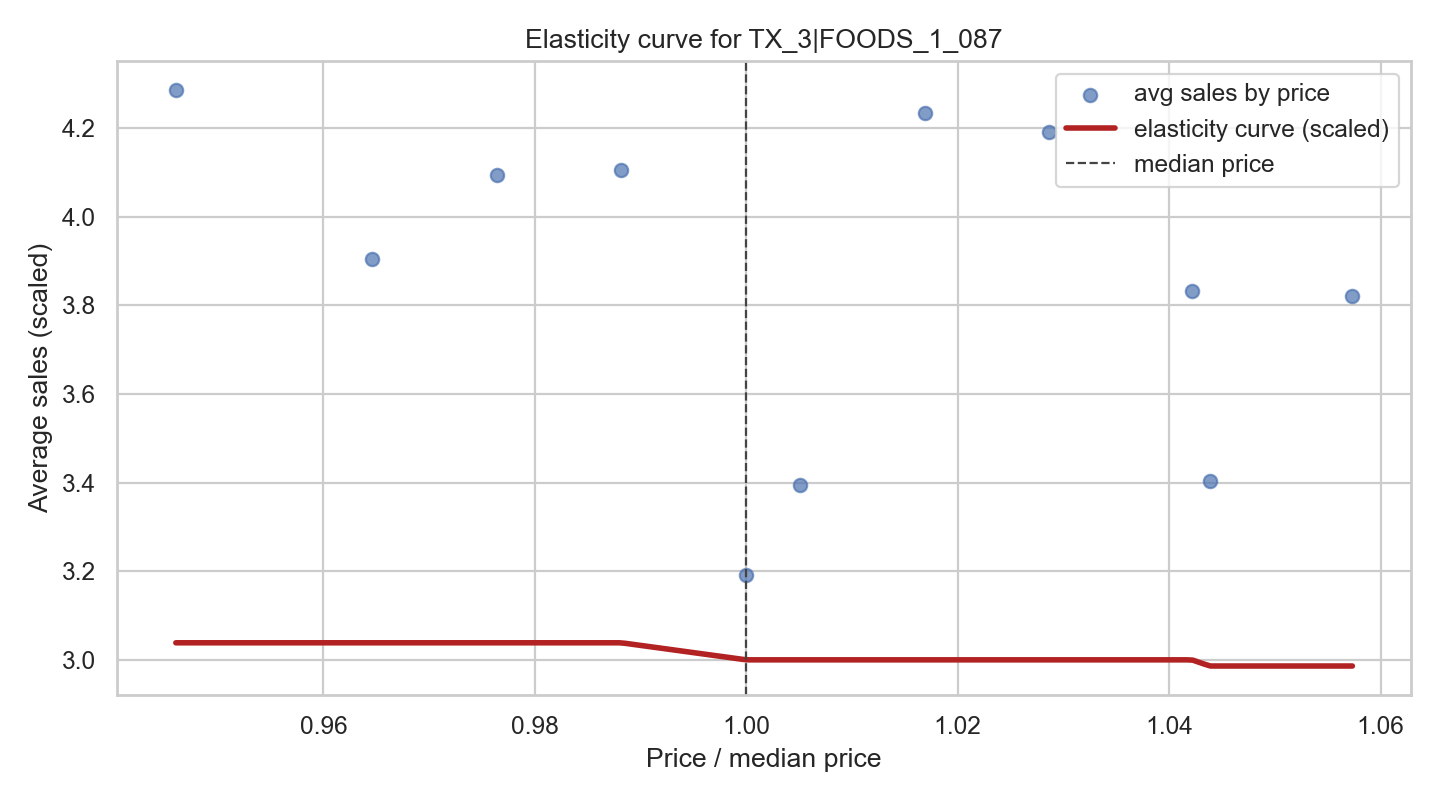

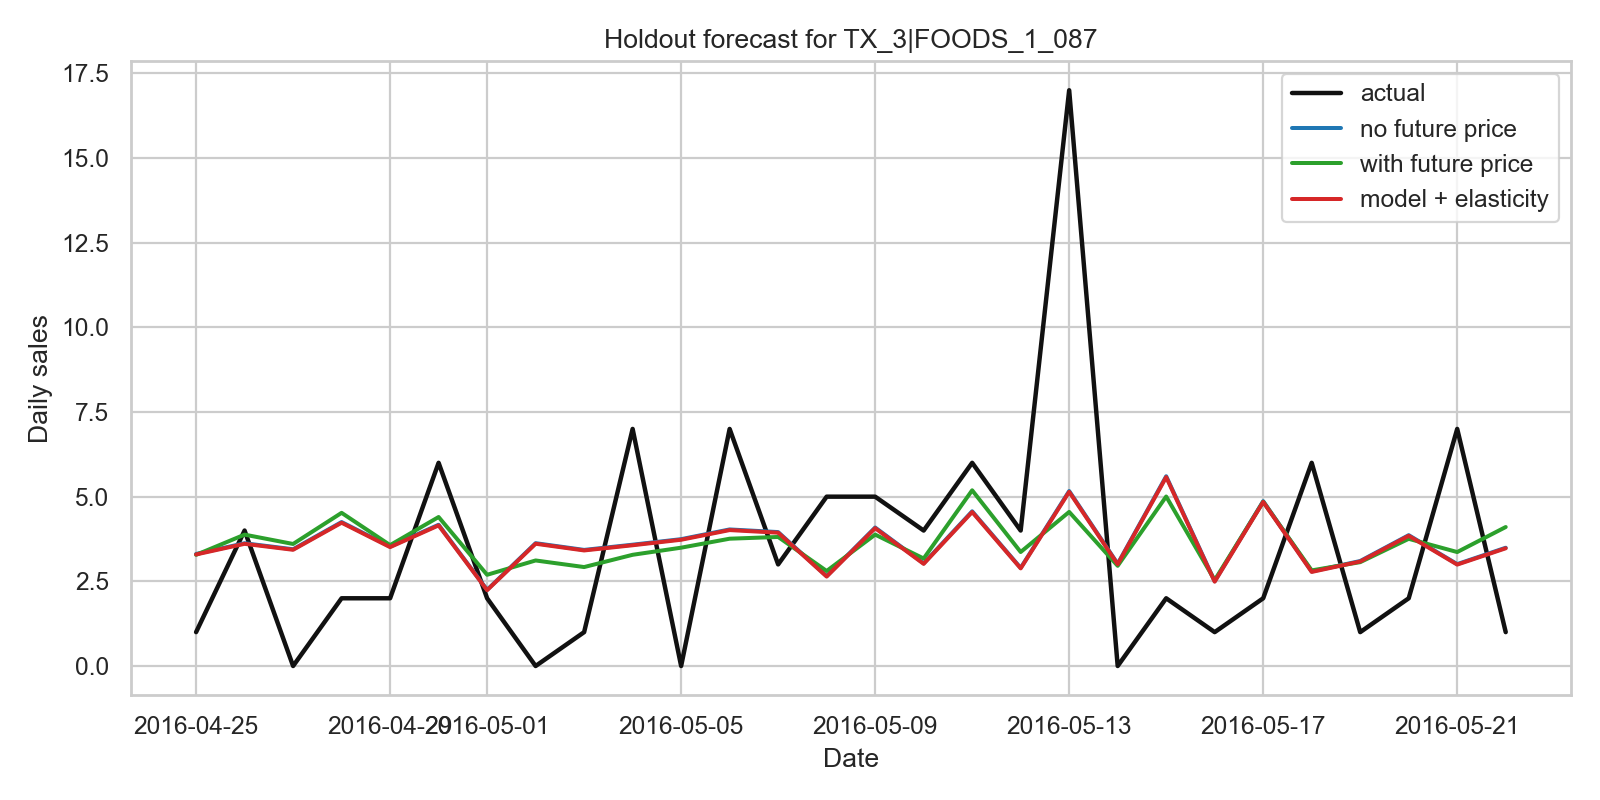

### TX_2|FOODS_1_129

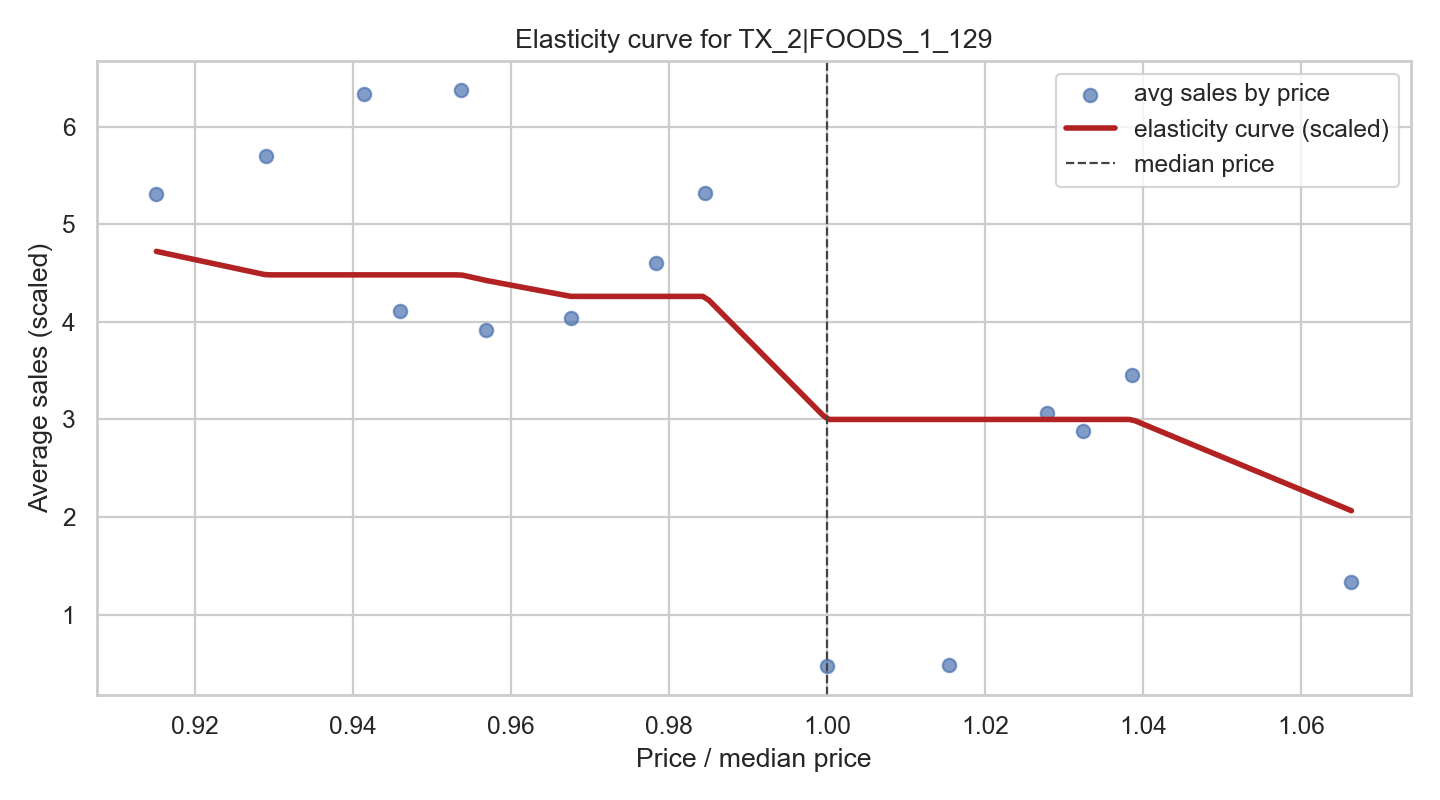

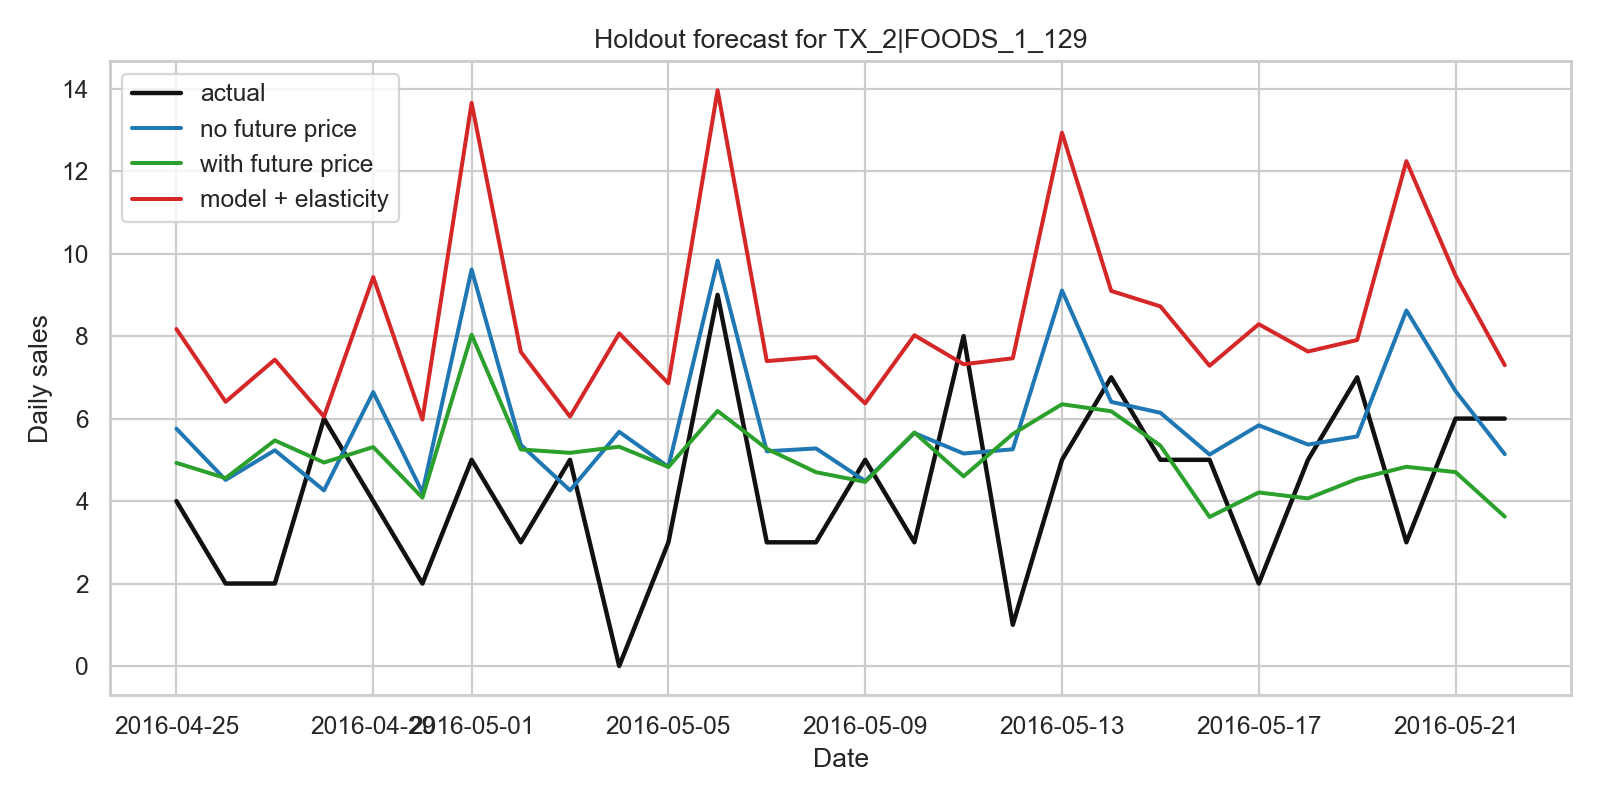

In [8]:
for sku_id in selected_skus["sku_id"]:
    display(Markdown(f"### {sku_id}"))
    display(Image(filename=str(FIGURES_DIR / f"elasticity_{sku_id.replace('|', '_')}.png")))
    display(Image(filename=str(FIGURES_DIR / f"forecast_{sku_id.replace('|', '_')}.png")))


## Общий анализ

- Если `Модель 2` лучше, значит будущая цена действительно несёт полезный сигнал и модель смогла его выучить.
- Если сильнее `Модель 3`, значит явная кривая спроса добавляет структуру, которую бустинг сам не вытащил.
- Если выигрывает `Модель 1`, цена либо слабо влияет на спрос, либо влияние нестабильно и тонет в шуме.

Что можно улучшить дальше:

- добавить иерархические признаки по категории и магазину;
- использовать rolling validation для настройки гиперпараметров;
- заменить локальную изотоническую кривую на байесовскую или сплайновую модель с доверительными интервалами;
- учесть каннибализацию, праздники и глубину промо отдельно.
